In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('Data_Caso_Propuesto.csv')
pd.set_option('display.float_format', '{:.2f}'.format)
df

,Codigo,Ciudad,Departamento,Barrio,Direccion,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble,Datos Adicionales
0,17180,BOGOTA,CUNDINAMARCA,NaN,AV CR 7 NO. 166 - 51 LT B,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,TRES,29580811900.00,LOTE COMERCIAL,ESTE INMUEBLE SE COMERCIALIZARÁ A TRAVES DE SU...
1,19292,BOGOTA,CUNDINAMARCA,NaN,CL 72 No. 12 - 77,0.00,0.00,COMERCIALIZABLE,COMERCIAL,16460591500.00,EDIFICIO,NaN
2,19292,BOGOTA,CUNDINAMARCA,NaN,CL 72 No. 12 - 77,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,COMERCIAL,16460591500.00,EDIFICIO,NaN
3,2575,SOGAMOSO,BOYACÁ,CENTRO,CRA. 10 #11- 78/80 Ó CL 12 # 9 - 77/85 Ó CALLE...,1655.08,7269.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,13768280900.00,CLINICA,ESTE INMUEBLE SE COMERCIALIZARÁ A TRAVÉS DE SU...
4,11409,BUGA,VALLE DEL CAUCA,VEREDA CHAMBIMBAL,LT A1-A24 B1-B79 C1-C51 D1-D9 STA ROSA LT1-46 ...,3217197.00,22724.00,COMERCIALIZABLE FIDUCIA,RURAL,45233789820.00,LOTE MIXTO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
458,12709,CALI,VALLE DEL CAUCA,PRADOS DEL NORTE,CL 30N # 2B-38 LOCAL 562 CENTRO COMERCIAL SA...,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,29605338.62,LOCAL,¡OPORTUNIDAD PARA INVERTIR! LOCAL EN PROINDIVI...
459,17992,BOGOTA,CUNDINAMARCA,NaN,CR 70 NO. 49-77,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,1448241600.00,CASA,NaN
460,12708,CALI,VALLE DEL CAUCA,PRADOS DEL NORTE,CL 30N # 2B-38 LOCAL 564 CENTRO COMERCIAL SAN...,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,20701337.03,LOCAL,¡OPORTUNIDAD PARA INVERTIR! LOCAL EN PROINDIVI...
461,12706,CALI,VALLE DEL CAUCA,PRADOS DEL NORTE,CL 30N # 2B-38 LOCAL 367 CENTRO COMERCIAL SAN...,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,20608003.68,LOCAL,¡OPORTUNIDAD PARA INVERTIR! LOCAL EN PROINDIVI...


In [3]:
df.shape

(463, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  463 non-null    int64  
 1   Ciudad                  463 non-null    object 
 2   Departamento            463 non-null    object 
 3   Barrio                  40 non-null     object 
 4   Direccion               463 non-null    object 
 5   Area Terreno            463 non-null    float64
 6   Area Construida         463 non-null    float64
 7   Detalle Disponibilidad  463 non-null    object 
 8   Estrato                 463 non-null    object 
 9   Precio                  463 non-null    float64
 10  Tipo de Inmueble        463 non-null    object 
 11  Datos Adicionales       118 non-null    object 
dtypes: float64(3), int64(1), object(8)
memory usage: 43.5+ KB


In [5]:
df.isnull().sum()

Codigo                      0
Ciudad                      0
Departamento                0
Barrio                    423
Direccion                   0
Area Terreno                0
Area Construida             0
Detalle Disponibilidad      0
Estrato                     0
Precio                      0
Tipo de Inmueble            0
Datos Adicionales         345
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop(columns=['Barrio', 'Direccion', 'Datos Adicionales'], inplace=True)

In [8]:
df.describe()

,Codigo,Area Terreno,Area Construida,Precio
count,463.00,463.00,463.00,463.00
mean,18003.15,15152.04,87.52,667203190.31
std,1992.19,182710.10,1137.47,3272992027.69
min,2575.00,0.00,0.00,4650000.00
25%,18184.50,0.00,0.00,12305000.00
50%,18332.00,0.00,0.00,15870000.00
75%,18539.50,0.00,0.00,137995500.00
max,19344.00,3217197.00,22724.00,45233789820.00


In [9]:
df.describe(include='object')

,Ciudad,Departamento,Detalle Disponibilidad,Estrato,Tipo de Inmueble
count,463,463,463,463,463
unique,43,14,6,9,19
top,VILLAVICENCIO,META,COMERCIALIZABLE,COMERCIAL,LOCAL
freq,290,292,289,307,305


In [10]:
df['Detalle Disponibilidad'].value_counts()

Detalle Disponibilidad
COMERCIALIZABLE                     289
COMERCIALIZABLE CON RESTRICCION      83
COMERCIALIZABLE TERCEROS             41
EN PUJA                              23
COMERCIALIZABLE VENTA ANTICIPADA     14
COMERCIALIZABLE FIDUCIA              13
Name: count, dtype: int64

In [11]:
df['Estrato'].value_counts()

Estrato
COMERCIAL     307
RURAL          40
UNO            21
TRES           19
CUATRO         19
INDUSTRIAL     16
DOS            16
SEIS           15
CINCO          10
Name: count, dtype: int64

In [12]:
df['Tipo de Inmueble'].value_counts()

Tipo de Inmueble
LOCAL                    305
LOTE VIVIENDA             48
BODEGA                    23
OFICINA                   17
CASA                      17
LOTE CON CONSTRUCCION     15
FINCA                     10
APARTAMENTO                7
EDIFICIO                   4
LOTE MIXTO                 3
LOTE                       3
CLINICA                    2
GARAJE                     2
LOTE INDUSTRIAL            2
DEPOSITO                   1
LOTE COMERCIAL             1
EDIFICIO OFICINAS          1
HOTEL                      1
LOTE AGRICOLA              1
Name: count, dtype: int64

In [13]:
precio = df.sort_values('Precio')
precio.head()

,Codigo,Ciudad,Departamento,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble
455,17009,VALENCIA,CÓRDOBA,0.00,0.00,COMERCIALIZABLE,RURAL,4650000.00,LOTE AGRICOLA
453,17337,PEREIRA,RISARALDA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,DOS,6333900.00,LOTE VIVIENDA
451,17336,PEREIRA,RISARALDA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,DOS,6832720.00,LOTE VIVIENDA
450,18447,VILLAVICENCIO,META,0.00,0.00,COMERCIALIZABLE,COMERCIAL,6835500.00,LOCAL
449,18137,VILLAVICENCIO,META,0.00,0.00,COMERCIALIZABLE,COMERCIAL,6884500.00,LOCAL


In [14]:
precio = df.sort_values('Precio', ascending = False)
precio.head()

,Codigo,Ciudad,Departamento,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble
4,11409,BUGA,VALLE DEL CAUCA,3217197.00,22724.00,COMERCIALIZABLE FIDUCIA,RURAL,45233789820.00,LOTE MIXTO
0,17180,BOGOTA,CUNDINAMARCA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,TRES,29580811900.00,LOTE COMERCIAL
19,17745,BOGOTA,CUNDINAMARCA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,INDUSTRIAL,25416536260.00,BODEGA
36,18640,LA DORADA,CALDAS,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,COMERCIAL,19522132996.00,FINCA
1,19292,BOGOTA,CUNDINAMARCA,0.00,0.00,COMERCIALIZABLE,COMERCIAL,16460591500.00,EDIFICIO


Text(0, 0.5, 'Cantidad')

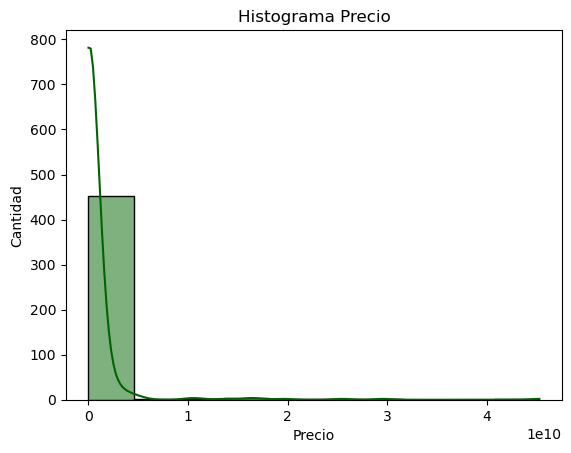

In [15]:
sns.histplot(df.Precio, color='darkgreen', bins=10, kde=True)
plt.title('Histograma Precio')
plt.xlabel('Precio')
plt.ylabel('Cantidad')

Text(0, 0.5, 'Cantidad')

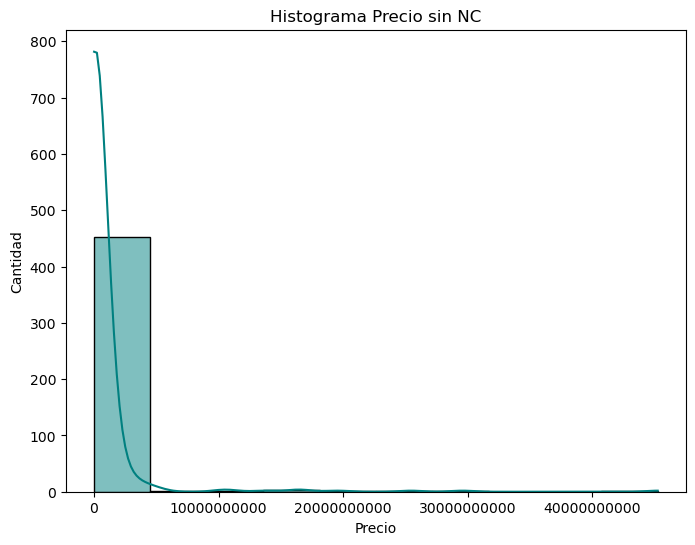

In [16]:
plt.figure(figsize=(8,6))
sns.histplot(df.Precio, color='teal', bins=10, kde=True)
plt.ticklabel_format(style='plain', axis='x')
plt.title('Histograma Precio sin NC')
plt.xlabel('Precio')
plt.ylabel('Cantidad')

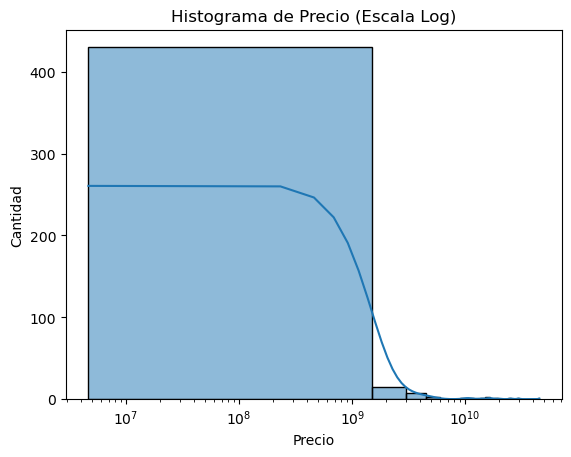

In [17]:
sns.histplot(df['Precio'], bins=30, kde=True)
plt.xscale('log')
plt.title('Histograma de Precio (Escala Log)')
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.show()


<Axes: ylabel='Precio'>

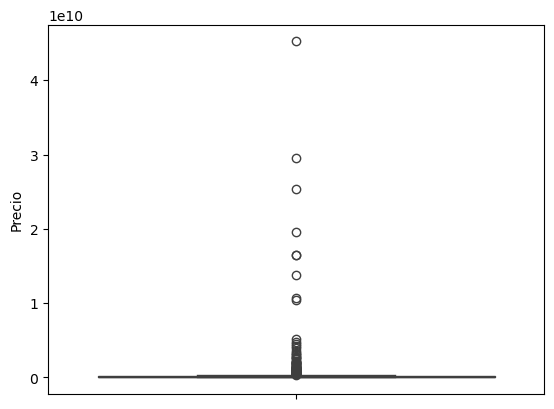

In [18]:
sns.boxplot(y=df['Precio'])

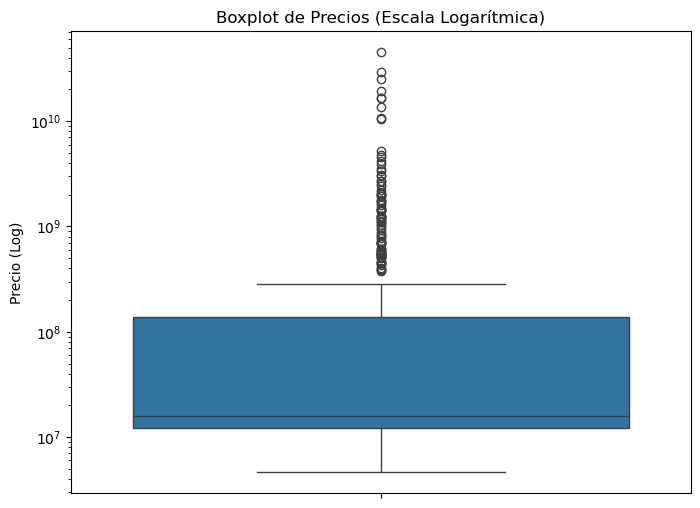

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Precio'])
plt.yscale('log') # Aplica la transformación logarítmica
plt.title('Boxplot de Precios (Escala Logarítmica)')
plt.ylabel('Precio (Log)')
plt.show()

# SIN OUTLIERS

In [20]:
Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

df_sin_outliers = df[(df['Precio'] >= limite_inferior) & (df['Precio'] <= limite_superior)]

print(f"Datos originales: {len(df)} filas")
print(f"Datos después de la limpieza IQR: {len(df_sin_outliers)} filas")

Datos originales: 463 filas
Datos después de la limpieza IQR: 377 filas


In [21]:
df_sin_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 377 entries, 50 to 462
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  377 non-null    int64  
 1   Ciudad                  377 non-null    object 
 2   Departamento            377 non-null    object 
 3   Area Terreno            377 non-null    float64
 4   Area Construida         377 non-null    float64
 5   Detalle Disponibilidad  377 non-null    object 
 6   Estrato                 377 non-null    object 
 7   Precio                  377 non-null    float64
 8   Tipo de Inmueble        377 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 29.5+ KB


In [22]:
df_sin_outliers.head()

,Codigo,Ciudad,Departamento,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble
50,19206,MEDELLIN,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,CINCO,268847500.00,OFICINA
51,19001,PUERTO BOYACA,BOYACÁ,0.00,0.00,COMERCIALIZABLE TERCEROS,UNO,268574800.00,CASA
53,19197,MONTERIA,CÓRDOBA,0.00,0.00,COMERCIALIZABLE TERCEROS,RURAL,264330000.00,FINCA
56,19205,MEDELLIN,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,CINCO,253872000.00,OFICINA
58,19341,TARAZA,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE TERCEROS,RURAL,230611914.00,LOTE CON CONSTRUCCION


In [23]:
df_sin_outliers.describe()

,Codigo,Area Terreno,Area Construida,Precio
count,377.00,377.00,377.00,377.00
mean,18284.02,8.15,0.00,33111054.28
std,824.05,158.27,0.00,54102467.84
min,12118.00,0.00,0.00,4650000.00
25%,18198.00,0.00,0.00,12305000.00
50%,18323.00,0.00,0.00,12936000.00
75%,18486.00,0.00,0.00,20381660.00
max,19341.00,3073.00,0.00,282520862.60


In [24]:
df_sin_outliers.describe(include='object')

,Ciudad,Departamento,Detalle Disponibilidad,Estrato,Tipo de Inmueble
count,377,377,377,377,377
unique,26,14,6,8,12
top,VILLAVICENCIO,META,COMERCIALIZABLE,COMERCIAL,LOCAL
freq,289,290,283,293,299


In [25]:
df_sin_outliers['Departamento'].value_counts()

Departamento
META               290
CALDAS              19
ATLÁNTICO           14
VALLE DEL CAUCA     11
RISARALDA           11
ANTIOQUIA           10
CUNDINAMARCA         7
CÓRDOBA              6
BOYACÁ               2
CHOCÓ                2
BOLÍVAR              2
PUTUMAYO             1
SANTANDER            1
CAUCA                1
Name: count, dtype: int64

In [26]:
df_sin_outliers['Ciudad'].value_counts()

Ciudad
VILLAVICENCIO             289
PACORA                     16
BARRANQUILLA               14
PEREIRA                    10
CALI                        8
BOGOTA                      6
TARAZA                      5
MEDELLIN                    4
VALENCIA                    3
MANIZALES                   2
PUERTO BOYACA               2
MONTERIA                    2
ACANDI                      2
CARTAGENA                   2
TIERRALTA                   1
TULUA                       1
NORCASIA                    1
PIEDECUESTA                 1
SAN MARTIN                  1
SONSON                      1
GIRARDOT                    1
BUENAVENTURA                1
SANTANDER DE QUILICHAO      1
SANMIGUEL                   1
CALIMA EL DARIEN            1
MARSELLA                    1
Name: count, dtype: int64

In [27]:
df_sin_outliers['Detalle Disponibilidad'].value_counts()

Detalle Disponibilidad
COMERCIALIZABLE                     283
COMERCIALIZABLE CON RESTRICCION      43
COMERCIALIZABLE TERCEROS             21
EN PUJA                              21
COMERCIALIZABLE VENTA ANTICIPADA      8
COMERCIALIZABLE FIDUCIA               1
Name: count, dtype: int64

In [28]:
df_sin_outliers['Estrato'].value_counts()

Estrato
COMERCIAL    293
UNO           21
RURAL         14
CUATRO        13
SEIS          12
DOS           11
TRES           8
CINCO          5
Name: count, dtype: int64

In [29]:
df_sin_outliers['Tipo de Inmueble'].value_counts()

Tipo de Inmueble
LOCAL                    299
LOTE VIVIENDA             35
OFICINA                   15
CASA                       7
FINCA                      5
LOTE CON CONSTRUCCION      5
APARTAMENTO                4
LOTE                       2
GARAJE                     2
LOTE MIXTO                 1
DEPOSITO                   1
LOTE AGRICOLA              1
Name: count, dtype: int64

In [30]:
precio = df_sin_outliers.sort_values('Precio', ascending = False)
precio.head()

,Codigo,Ciudad,Departamento,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble
456,16752,PEREIRA,RISARALDA,0.00,0.00,COMERCIALIZABLE,CUATRO,282520862.60,LOTE VIVIENDA
50,19206,MEDELLIN,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,CINCO,268847500.00,OFICINA
51,19001,PUERTO BOYACA,BOYACÁ,0.00,0.00,COMERCIALIZABLE TERCEROS,UNO,268574800.00,CASA
53,19197,MONTERIA,CÓRDOBA,0.00,0.00,COMERCIALIZABLE TERCEROS,RURAL,264330000.00,FINCA
56,19205,MEDELLIN,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,CINCO,253872000.00,OFICINA


In [31]:
precio = df_sin_outliers.sort_values('Precio')
precio.head()

,Codigo,Ciudad,Departamento,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble
455,17009,VALENCIA,CÓRDOBA,0.00,0.00,COMERCIALIZABLE,RURAL,4650000.00,LOTE AGRICOLA
453,17337,PEREIRA,RISARALDA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,DOS,6333900.00,LOTE VIVIENDA
451,17336,PEREIRA,RISARALDA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,DOS,6832720.00,LOTE VIVIENDA
450,18447,VILLAVICENCIO,META,0.00,0.00,COMERCIALIZABLE,COMERCIAL,6835500.00,LOCAL
449,18137,VILLAVICENCIO,META,0.00,0.00,COMERCIALIZABLE,COMERCIAL,6884500.00,LOCAL


## 1. Análisis Univariado

### Precio

Text(0, 0.5, 'Cantidad')

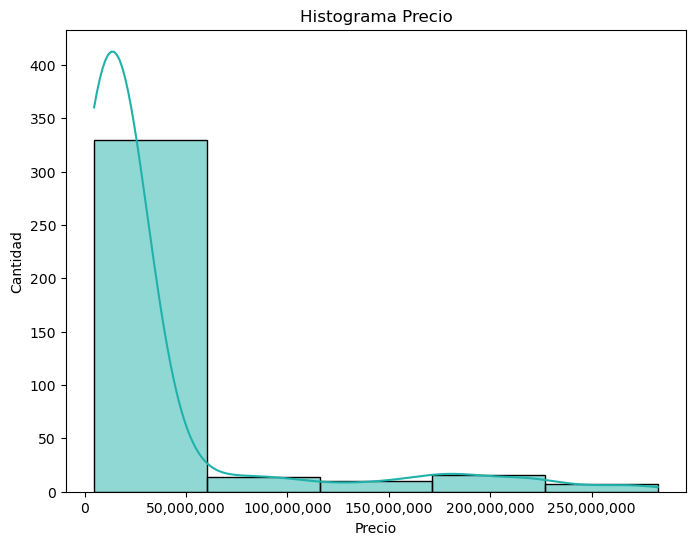

In [32]:
plt.figure(figsize=(8, 6))
sns.histplot(df_sin_outliers.Precio, color='lightseagreen', bins=5, kde=True)
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('Histograma Precio')
plt.xlabel('Precio')
plt.ylabel('Cantidad')

In [33]:
df_sin_outliers["Precio_log"] = np.log(df_sin_outliers["Precio"])
df_sin_outliers

C:\Users\USER\AppData\Local\Temp\ipykernel_150372\3805663166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers["Precio_log"] = np.log(df_sin_outliers["Precio"])


,Codigo,Ciudad,Departamento,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble,Precio_log
50,19206,MEDELLIN,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,CINCO,268847500.00,OFICINA,19.41
51,19001,PUERTO BOYACA,BOYACÁ,0.00,0.00,COMERCIALIZABLE TERCEROS,UNO,268574800.00,CASA,19.41
53,19197,MONTERIA,CÓRDOBA,0.00,0.00,COMERCIALIZABLE TERCEROS,RURAL,264330000.00,FINCA,19.39
56,19205,MEDELLIN,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE VENTA ANTICIPADA,CINCO,253872000.00,OFICINA,19.35
58,19341,TARAZA,ANTIOQUIA,0.00,0.00,COMERCIALIZABLE TERCEROS,RURAL,230611914.00,LOTE CON CONSTRUCCION,19.26
...,...,...,...,...,...,...,...,...,...,...
457,16909,MARSELLA,RISARALDA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,DOS,24000000.00,LOCAL,16.99
458,12709,CALI,VALLE DEL CAUCA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,29605338.62,LOCAL,17.20
460,12708,CALI,VALLE DEL CAUCA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,20701337.03,LOCAL,16.85
461,12706,CALI,VALLE DEL CAUCA,0.00,0.00,COMERCIALIZABLE CON RESTRICCION,CUATRO,20608003.68,LOCAL,16.84


In [34]:
df_sin_outliers.describe()

,Codigo,Area Terreno,Area Construida,Precio,Precio_log
count,377.00,377.00,377.00,377.00,377.00
mean,18284.02,8.15,0.00,33111054.28,16.70
std,824.05,158.27,0.00,54102467.84,0.91
min,12118.00,0.00,0.00,4650000.00,15.35
25%,18198.00,0.00,0.00,12305000.00,16.33
50%,18323.00,0.00,0.00,12936000.00,16.38
75%,18486.00,0.00,0.00,20381660.00,16.83
max,19341.00,3073.00,0.00,282520862.60,19.46


Text(0, 0.5, 'Cantidad')

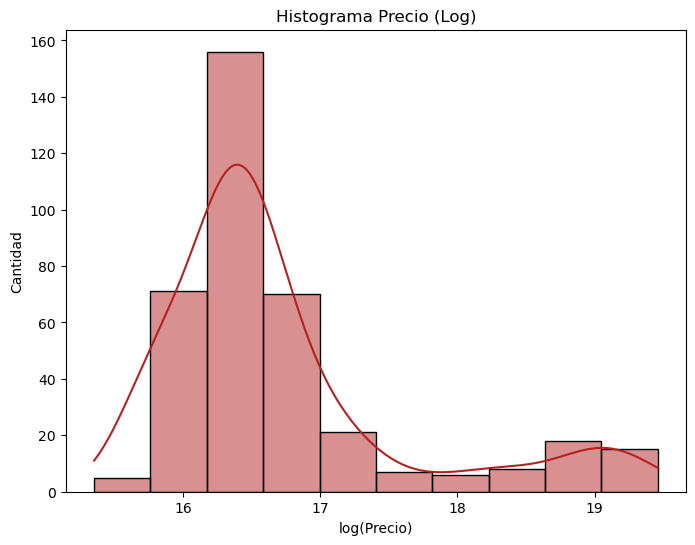

In [35]:
plt.figure(figsize=(8,6))
sns.histplot(df_sin_outliers.Precio_log, kde=True, bins=10, color='firebrick')
plt.title('Histograma Precio (Log)')
plt.xlabel('log(Precio)')
plt.ylabel('Cantidad')

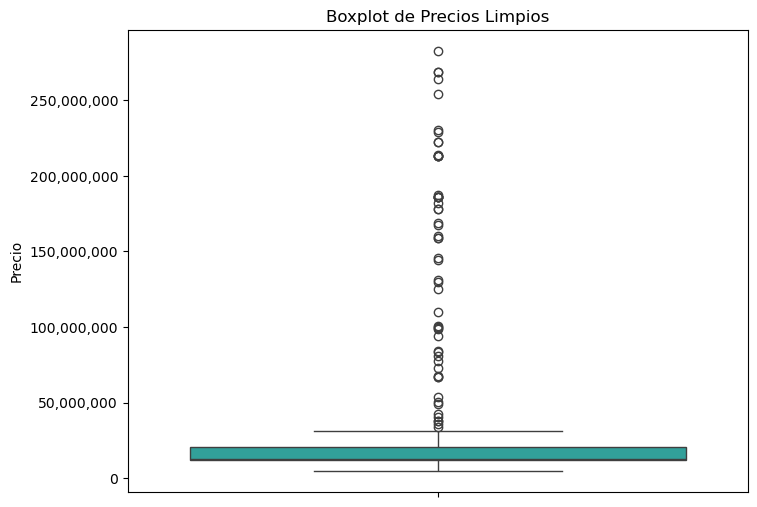

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_sin_outliers['Precio'], color='lightseagreen')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('Boxplot de Precios Limpios')
plt.ylabel('Precio')
plt.show()

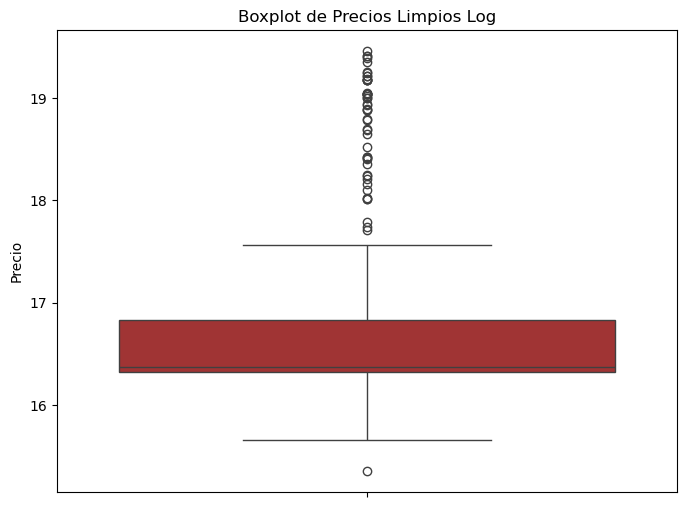

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_sin_outliers['Precio_log'], color='firebrick')
#plt.yscale('log')
plt.title('Boxplot de Precios Limpios Log')
plt.ylabel('Precio')
plt.show()

### Departamento

In [38]:
top_dpto = df_sin_outliers['Departamento'].value_counts().head(10)
top_dpto

Departamento
META               290
CALDAS              19
ATLÁNTICO           14
VALLE DEL CAUCA     11
RISARALDA           11
ANTIOQUIA           10
CUNDINAMARCA         7
CÓRDOBA              6
BOYACÁ               2
CHOCÓ                2
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_150372\4135266196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_dpto.values, y=top_dpto.index, palette="tab20")


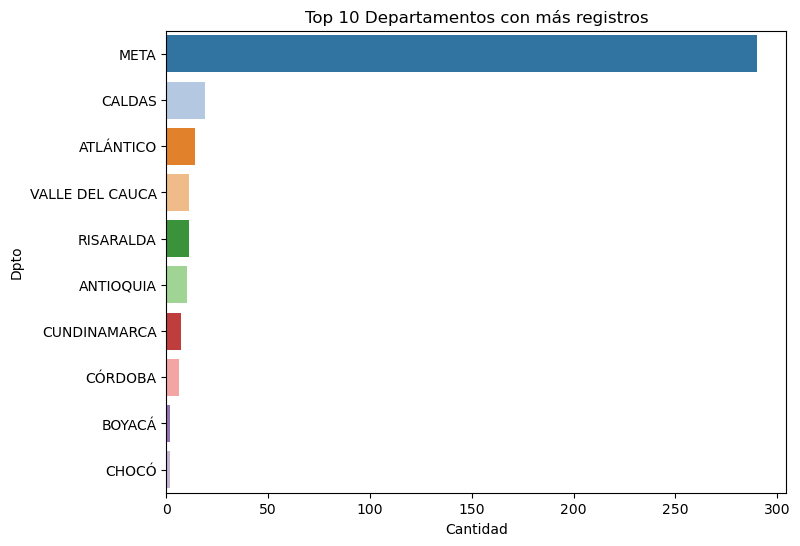

In [39]:
plt.figure(figsize=(8,6))
top_dpto = df_sin_outliers['Departamento'].value_counts().head(10)
sns.barplot(x=top_dpto.values, y=top_dpto.index, palette="tab20")
plt.title("Top 10 Departamentos con más registros")
plt.xlabel("Cantidad")
plt.ylabel("Dpto")
plt.show()

### Ciudad

In [40]:
top_ciudades = df_sin_outliers['Ciudad'].value_counts().head(10)
top_ciudades

Ciudad
VILLAVICENCIO    289
PACORA            16
BARRANQUILLA      14
PEREIRA           10
CALI               8
BOGOTA             6
TARAZA             5
MEDELLIN           4
VALENCIA           3
MANIZALES          2
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_150372\3459204478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ciudades.values, y=top_ciudades.index, palette="tab20")


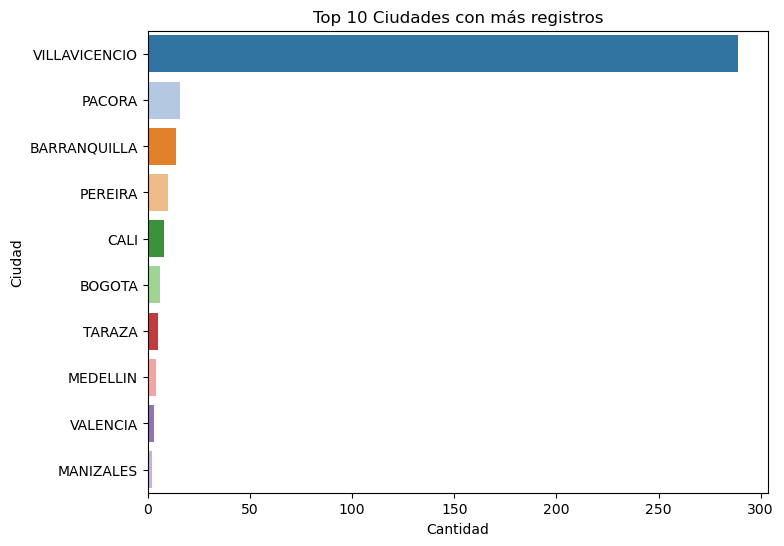

In [41]:
plt.figure(figsize=(8,6))
top_ciudades = df_sin_outliers['Ciudad'].value_counts().head(10)
sns.barplot(x=top_ciudades.values, y=top_ciudades.index, palette="tab20")
plt.title("Top 10 Ciudades con más registros")
plt.xlabel("Cantidad")
plt.ylabel("Ciudad")
plt.show()


### Tipo de Inmueble

In [42]:
inmuebles = df_sin_outliers['Tipo de Inmueble'].value_counts()
inmuebles

Tipo de Inmueble
LOCAL                    299
LOTE VIVIENDA             35
OFICINA                   15
CASA                       7
FINCA                      5
LOTE CON CONSTRUCCION      5
APARTAMENTO                4
LOTE                       2
GARAJE                     2
LOTE MIXTO                 1
DEPOSITO                   1
LOTE AGRICOLA              1
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_150372\746779133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inmuebles.values, y=inmuebles.index, palette="tab20")


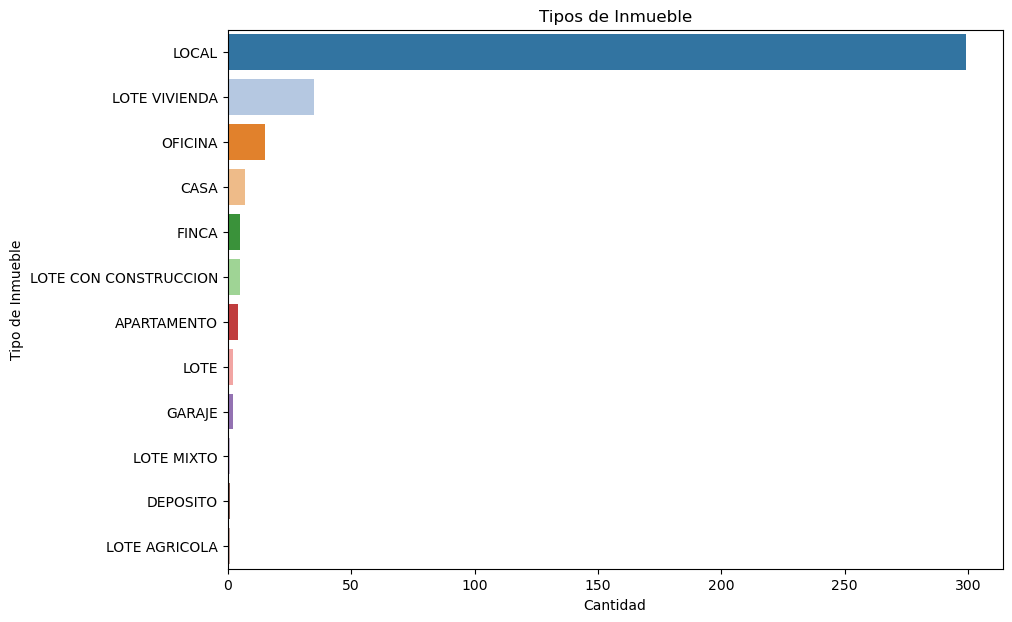

In [43]:
plt.figure(figsize=(10,7))
inmuebles = df_sin_outliers['Tipo de Inmueble'].value_counts()
sns.barplot(x=inmuebles.values, y=inmuebles.index, palette="tab20")
plt.title("Tipos de Inmueble")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de Inmueble")
plt.show()


### Estrato

In [44]:
estrato = df_sin_outliers['Estrato'].value_counts()
estrato

Estrato
COMERCIAL    293
UNO           21
RURAL         14
CUATRO        13
SEIS          12
DOS           11
TRES           8
CINCO          5
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_150372\1512366353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=estrato.values, y=estrato.index, palette="tab20")


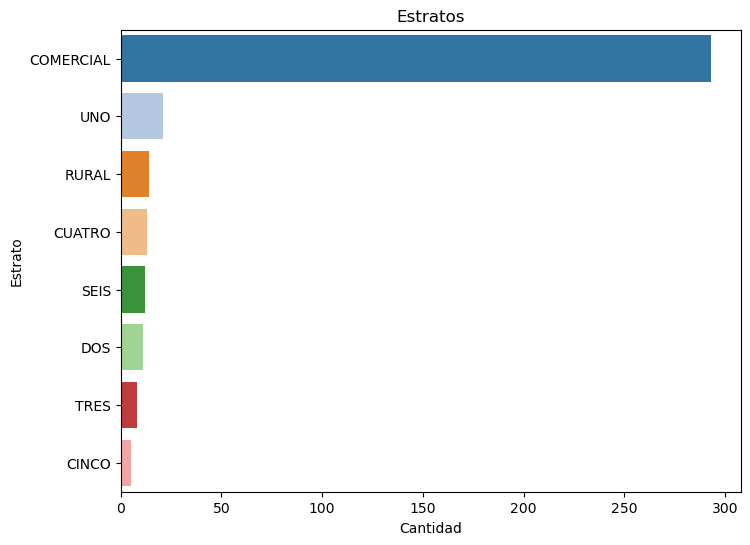

In [45]:
plt.figure(figsize=(8,6))
estrato = df_sin_outliers['Estrato'].value_counts()
sns.barplot(x=estrato.values, y=estrato.index, palette="tab20")
plt.title("Estratos")
plt.xlabel("Cantidad")
plt.ylabel("Estrato")
plt.show()

### Detalle Disponibilidad

In [46]:
disp = df_sin_outliers['Detalle Disponibilidad'].value_counts()
disp

Detalle Disponibilidad
COMERCIALIZABLE                     283
COMERCIALIZABLE CON RESTRICCION      43
COMERCIALIZABLE TERCEROS             21
EN PUJA                              21
COMERCIALIZABLE VENTA ANTICIPADA      8
COMERCIALIZABLE FIDUCIA               1
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_150372\1055525060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disp.values, y=disp.index, palette="tab20")


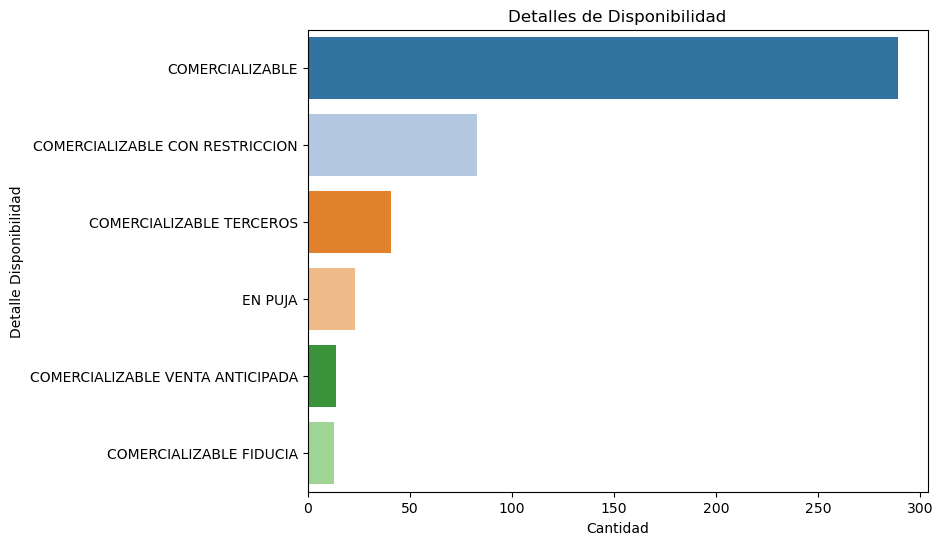

In [47]:
plt.figure(figsize=(8,6))
disp = df['Detalle Disponibilidad'].value_counts()
sns.barplot(x=disp.values, y=disp.index, palette="tab20")
plt.title("Detalles de Disponibilidad")
plt.xlabel("Cantidad")
plt.ylabel("Detalle Disponibilidad")
plt.show()


## 2. Análisis Bivariado

### Precio por Ciudad (normal)

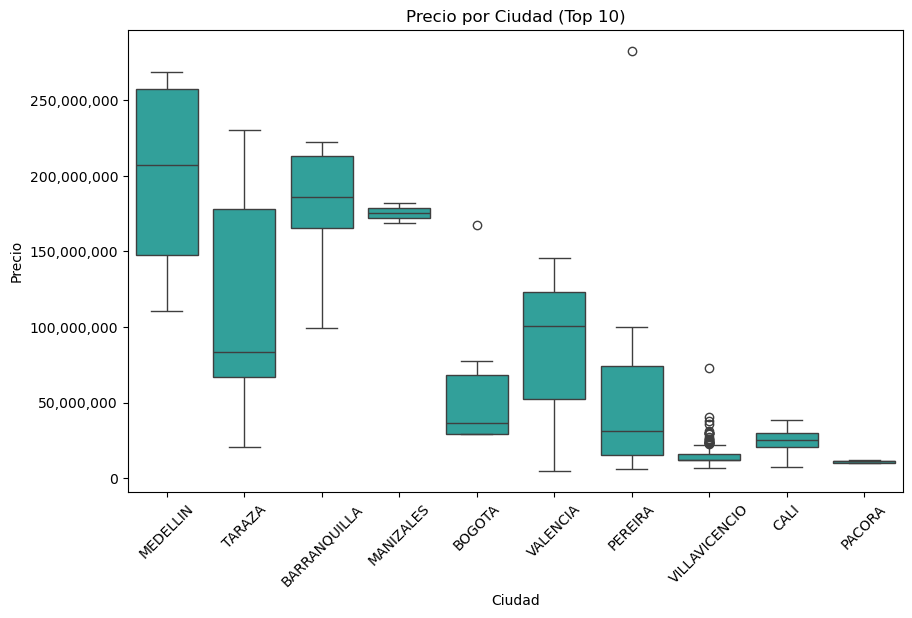

In [48]:
top_ciudades = df_sin_outliers['Ciudad'].value_counts().head(10).index
df_ciu = df_sin_outliers[df_sin_outliers['Ciudad'].isin(top_ciudades)]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_ciu, x='Ciudad', y='Precio', color='lightseagreen')
#plt.yscale('log')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Ciudad (Top 10)")
plt.show()

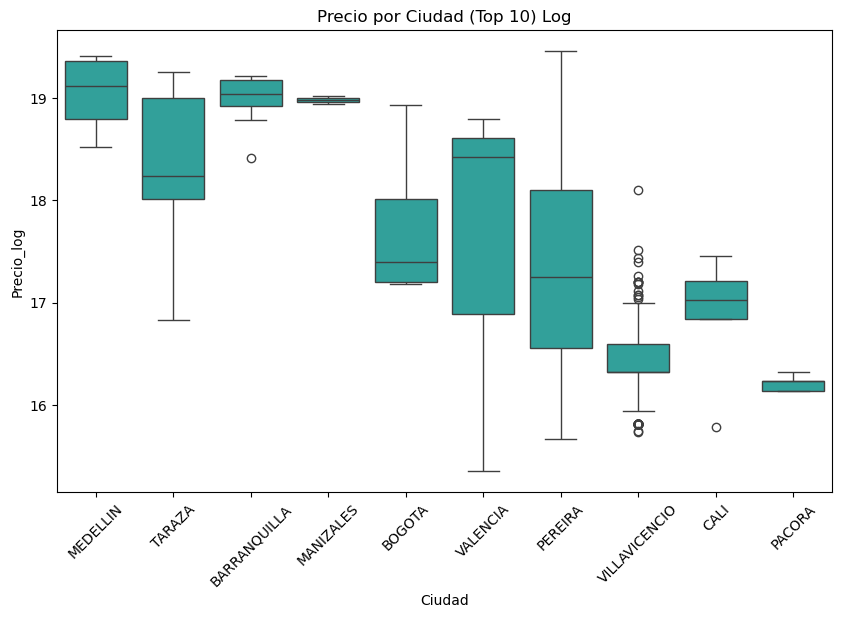

In [61]:
top_ciudades = df_sin_outliers['Ciudad'].value_counts().head(10).index
df_ciu = df_sin_outliers[df_sin_outliers['Ciudad'].isin(top_ciudades)]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_ciu, x='Ciudad', y='Precio_log', color='lightseagreen')
#plt.yscale('log')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Ciudad (Top 10) Log")
plt.show()

### Precio por Tipo de Inmueble

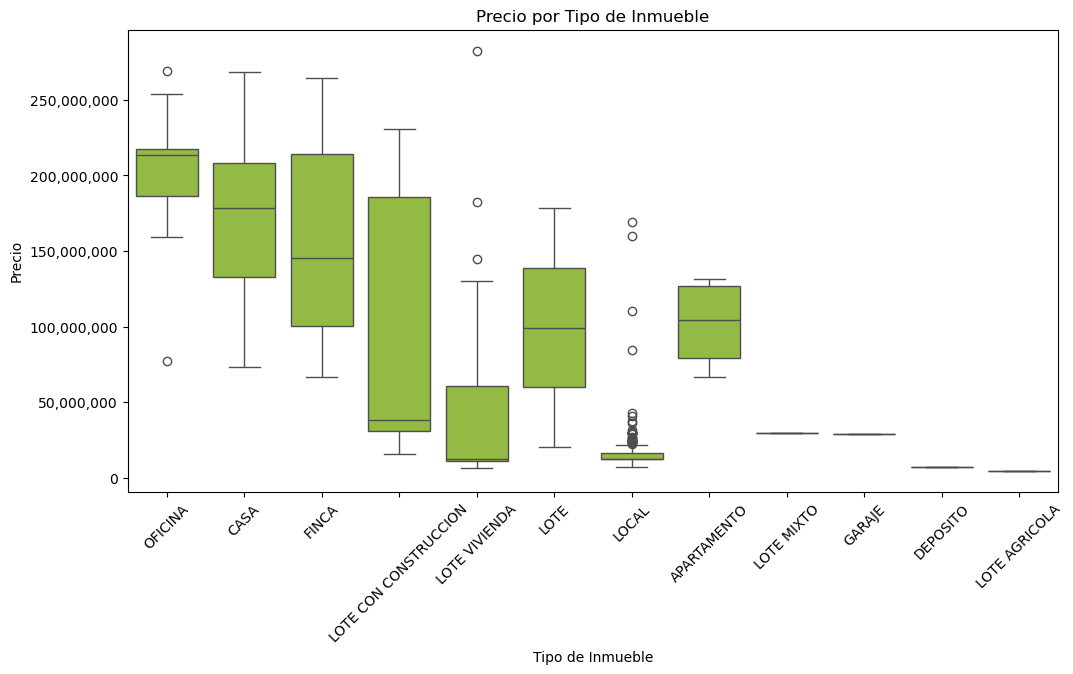

In [50]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_sin_outliers, x='Tipo de Inmueble', y='Precio', color='yellowgreen')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Tipo de Inmueble")
plt.show()

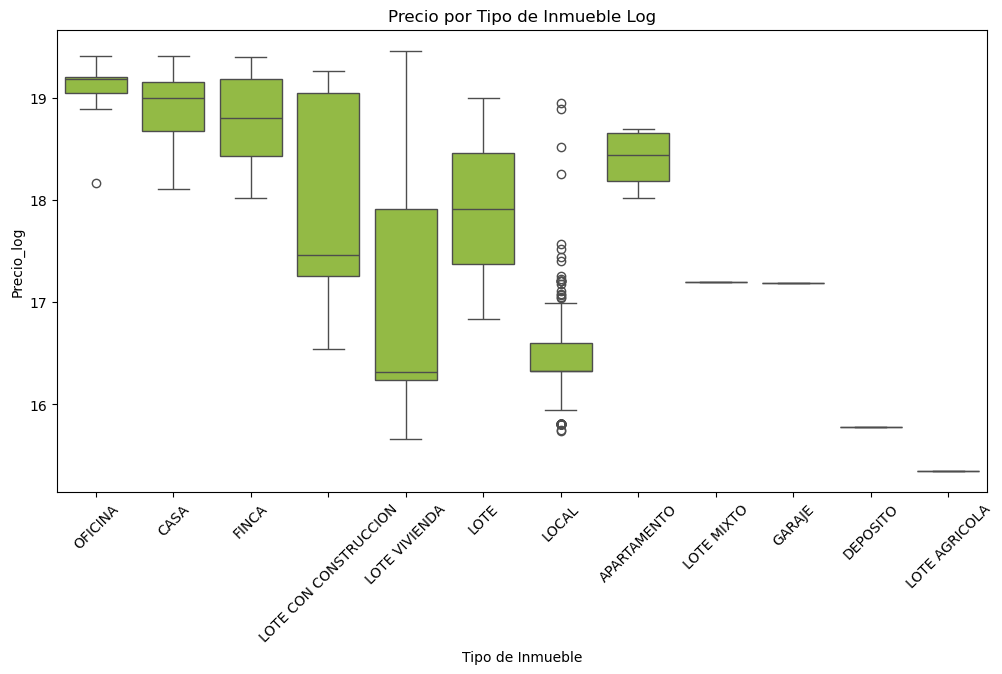

In [62]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_sin_outliers, x='Tipo de Inmueble', y='Precio_log', color='yellowgreen')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Tipo de Inmueble Log")
plt.show()


### Precio por Estrato

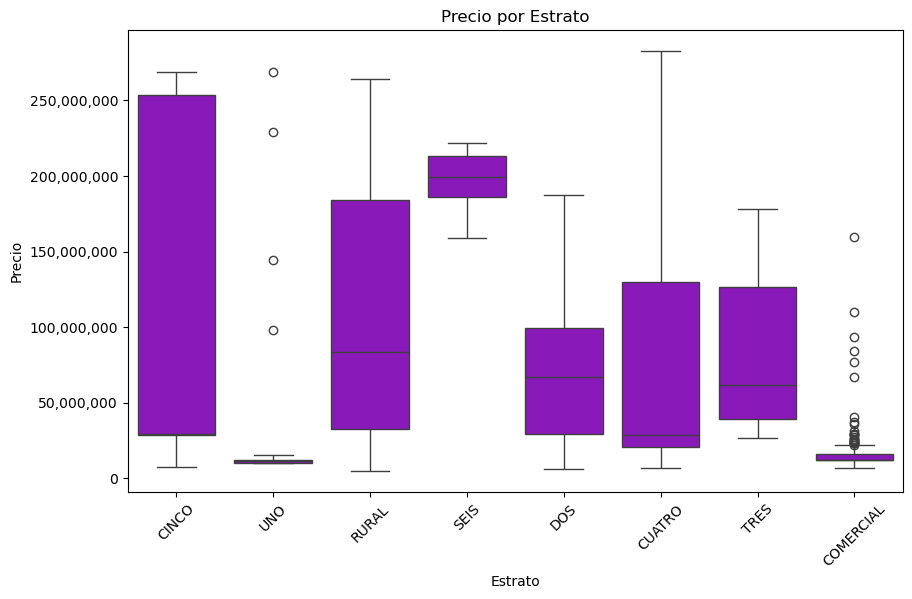

In [52]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_sin_outliers, x='Estrato', y='Precio', color='darkviolet')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Estrato")
plt.show()

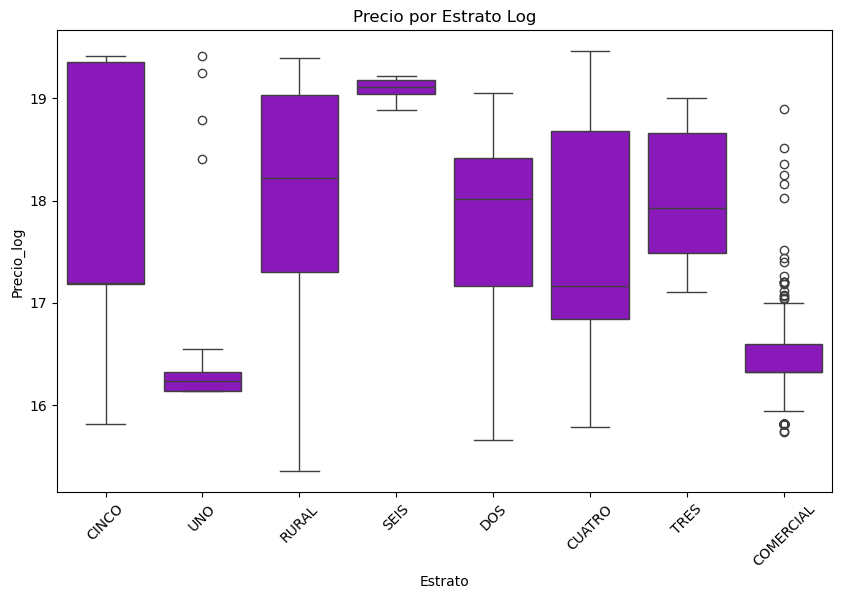

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_sin_outliers, x='Estrato', y='Precio_log', color='darkviolet')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Estrato Log")
plt.show()

### Precio por Detalle Disponibilidad

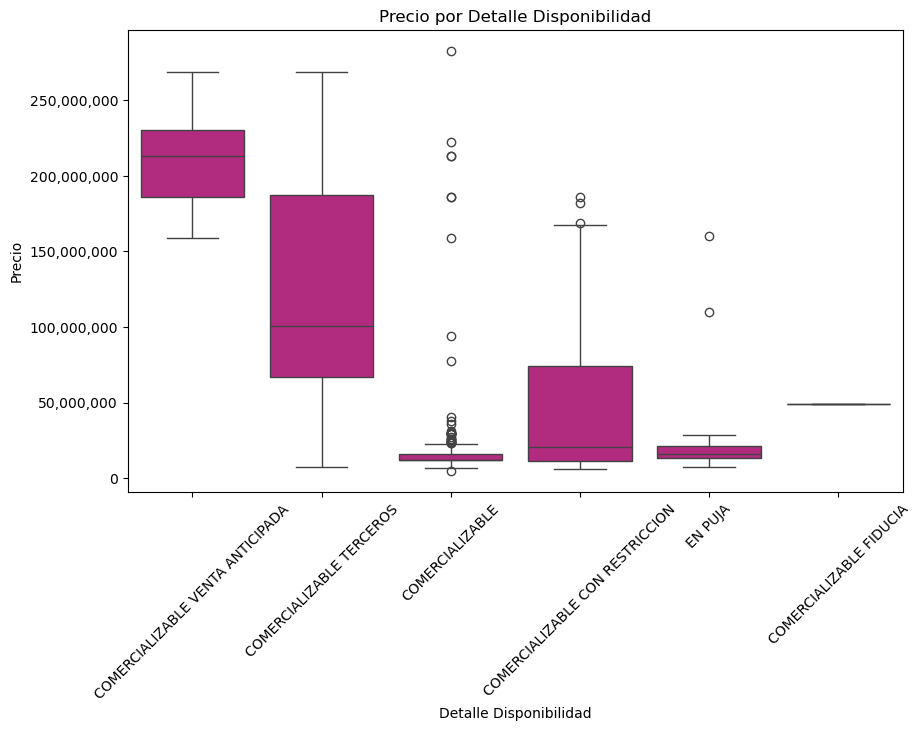

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_sin_outliers, x='Detalle Disponibilidad', y='Precio', color='mediumvioletred')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Detalle Disponibilidad")
plt.show()

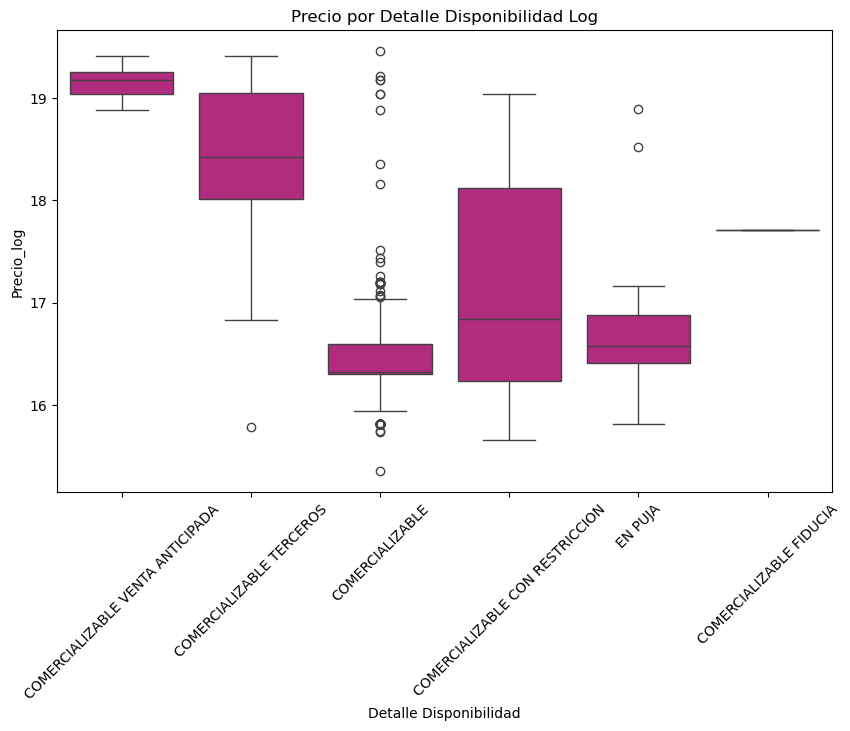

In [64]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_sin_outliers, x='Detalle Disponibilidad', y='Precio_log', color='mediumvioletred')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Precio por Detalle Disponibilidad Log")
plt.show()

## Análisis Multivariado

### Mapa de Calor

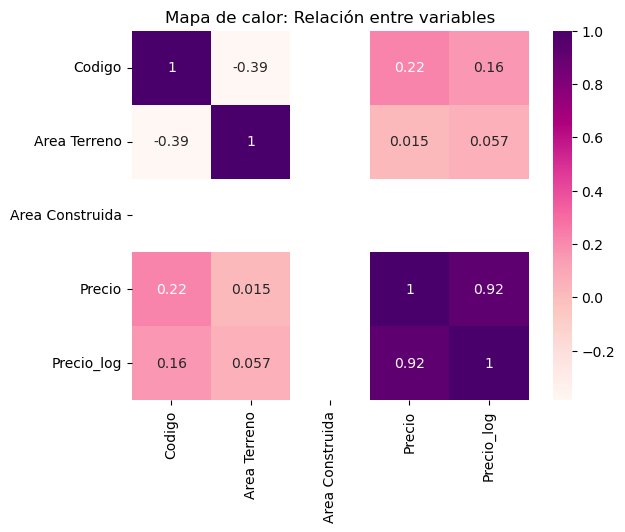

In [56]:
sns.heatmap(df_sin_outliers.corr(numeric_only = True),annot=True, cmap="RdPu")
plt.title('Mapa de calor: Relación entre variables')
plt.show()

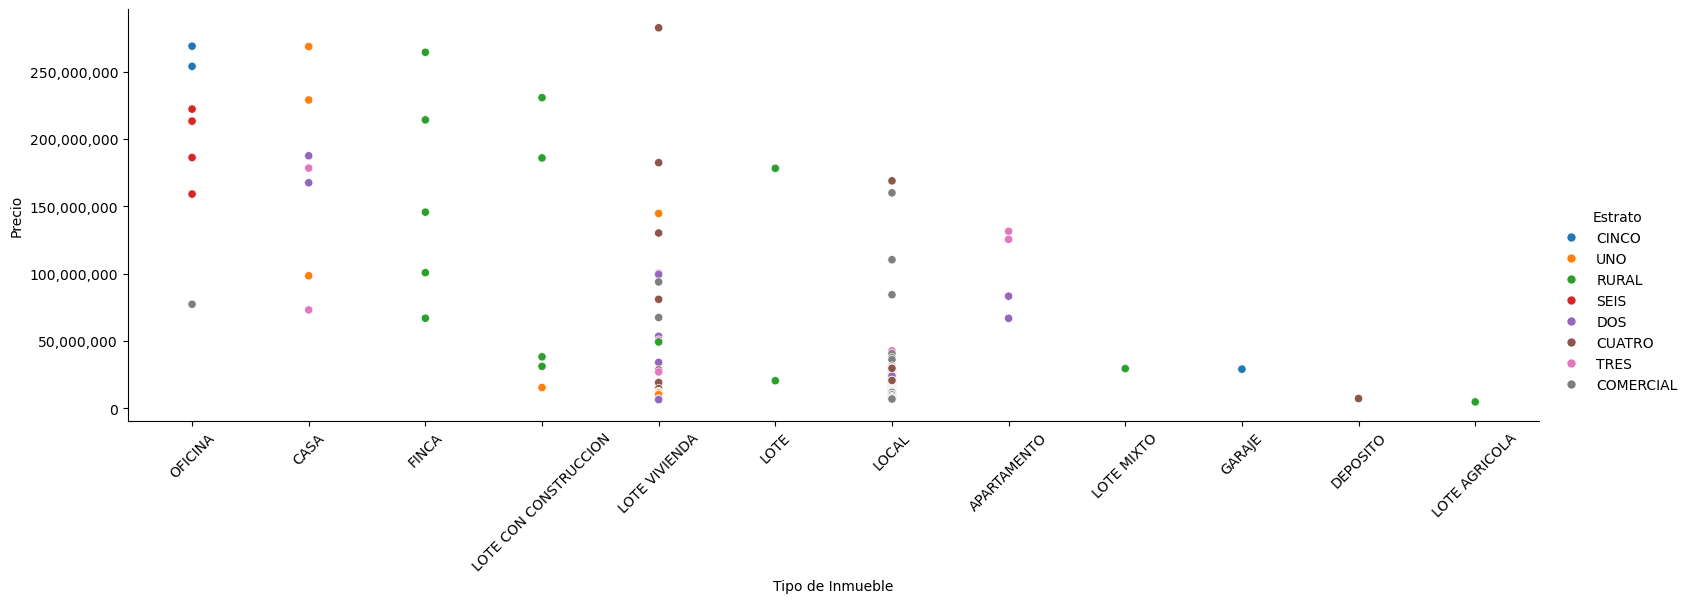

In [57]:
sns.relplot(x='Tipo de Inmueble' ,y='Precio',hue='Estrato',data=df_sin_outliers, aspect = 3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

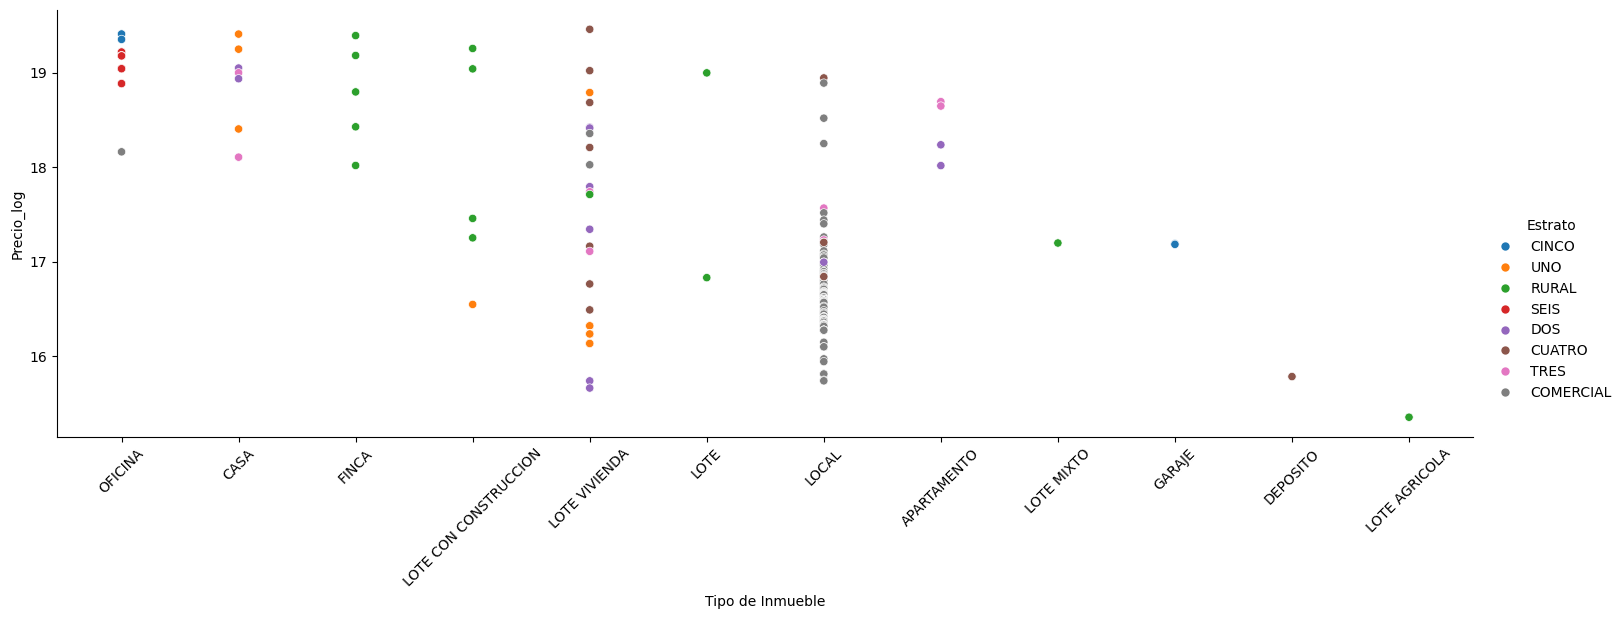

In [58]:
sns.relplot(x='Tipo de Inmueble' ,y='Precio_log',hue='Estrato',data=df_sin_outliers, aspect = 3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

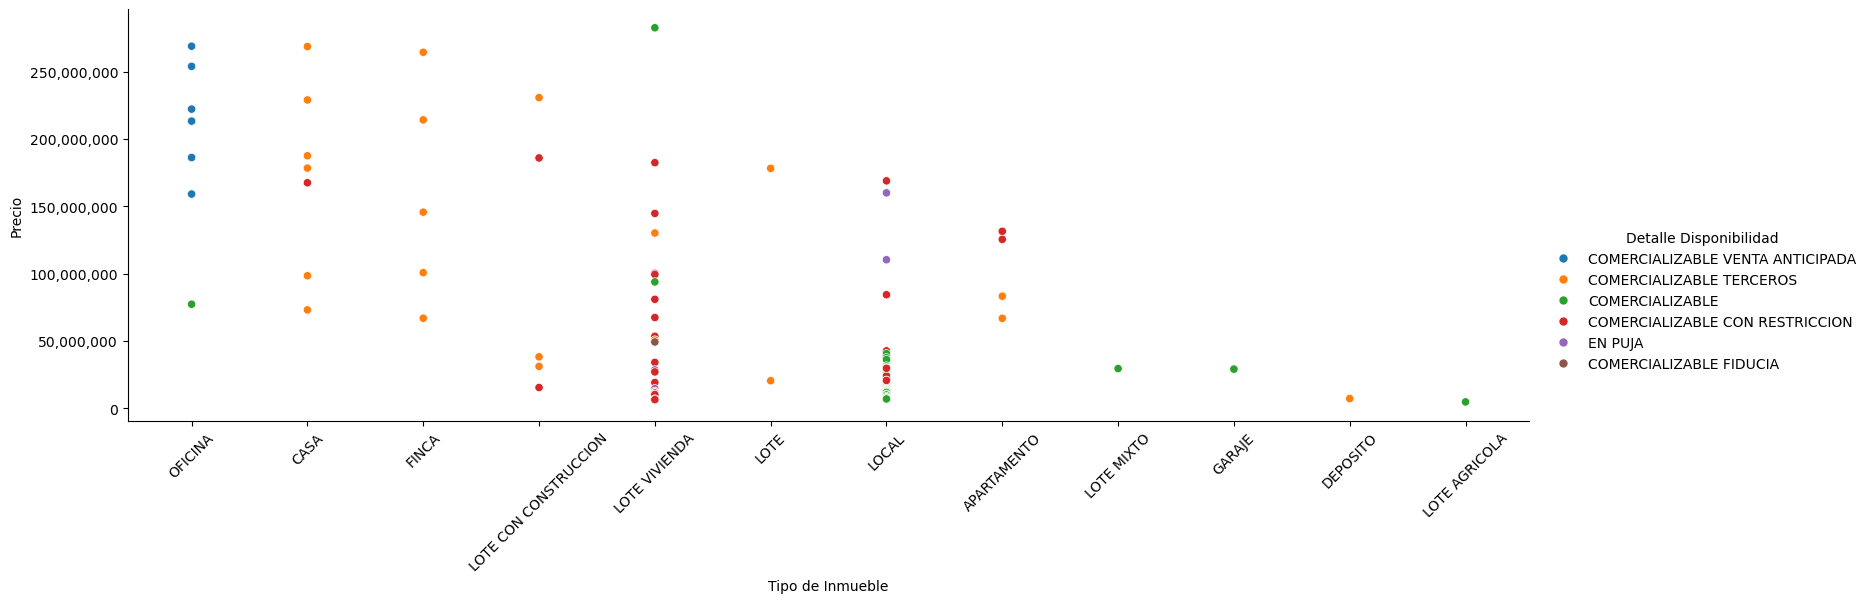

In [59]:
sns.relplot(x='Tipo de Inmueble' ,y='Precio',hue='Detalle Disponibilidad',data=df_sin_outliers, aspect = 3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

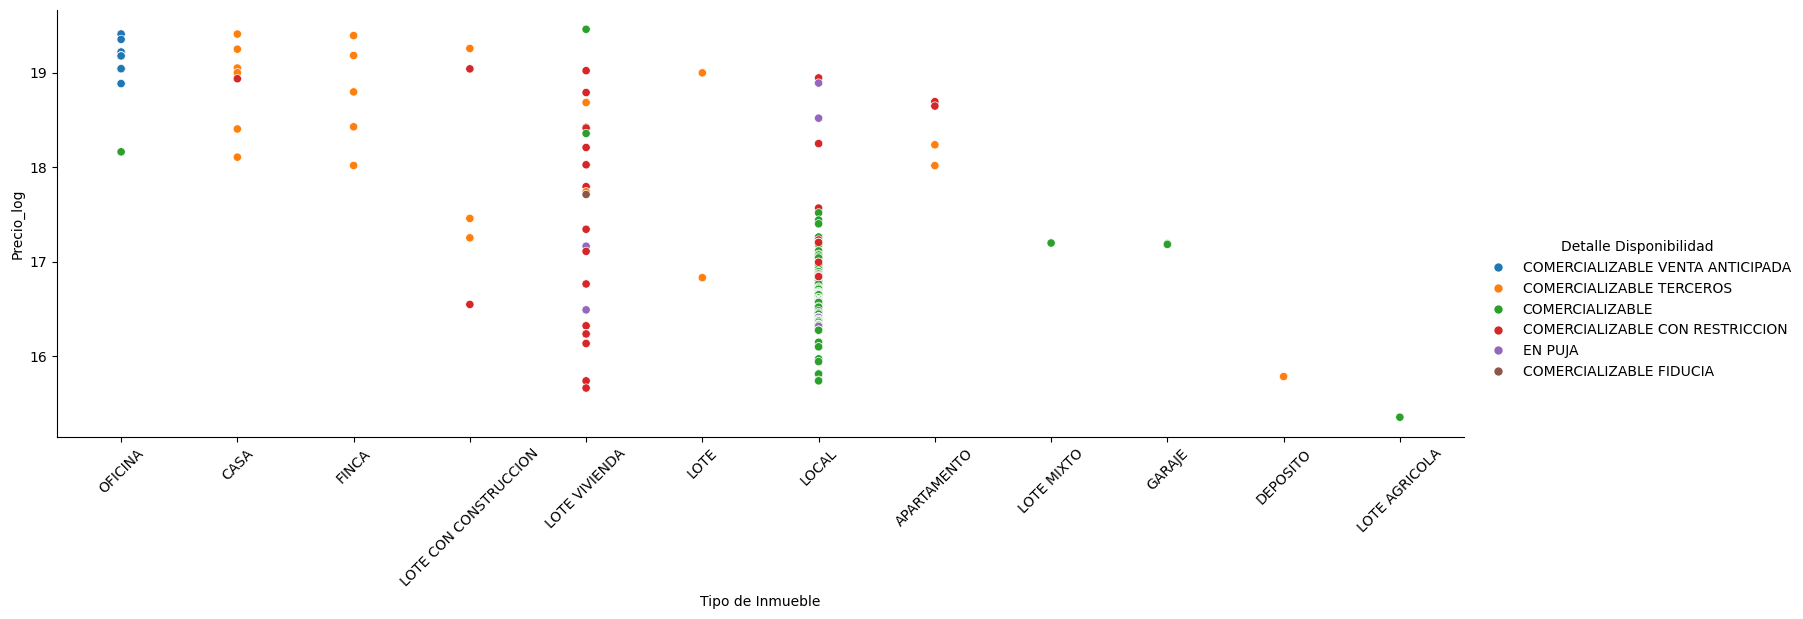

In [60]:
sns.relplot(x='Tipo de Inmueble' ,y='Precio_log',hue='Detalle Disponibilidad',data=df_sin_outliers, aspect = 3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))